# Expansion Methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyFBS

### Generate parent and overlay model

In [2]:
pyFBS.io.download_lab_testbench()

100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 8630.26it/s]


100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 4462.03it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 9993.58it/s]


In [3]:
pos_xlsx = r"./lab_testbench/Measurements/expansion_synt_example.xlsx"

df_chn_P = pd.read_excel(pos_xlsx,sheet_name = 'chn_parent')
df_chn_O = pd.read_excel(pos_xlsx,sheet_name = 'chn_overlay')

In [4]:
folder = r'./lab_testbench/FEM//'

MK_P = pyFBS.mck.Model.from_ansys(folder+'AB_parent.rst', folder+'AB_parent.full', mesh_scale=1000, no_modes=30, read_rst=True)
MK_O = pyFBS.mck.Model.from_ansys(folder+'AB_overlay.rst', folder+'AB_overlay.full', mesh_scale=1000, no_modes=30, read_rst=True)

C:\Users\ga83top\AppData\Local\anaconda3\envs\myenv\Lib\site-packages\ansys\mapdl\reader\mesh.py:247: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  mask = np.in1d(nnum, item, assume_unique=True)
C:\Users\ga83top\AppData\Local\anaconda3\envs\myenv\Lib\site-packages\ansys\mapdl\reader\rst.py:1836: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  self._insolution = np.in1d(
C:\Users\ga83top\AppData\Local\anaconda3\envs\myenv\Lib\site-packages\ansys\mapdl\reader\full.py:386: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  mask = ~np.logical_or(np.in1d(krow, remove), np.in1d(kcol, remove))
C:\Users\ga83top\AppData\Local\anaconda3\envs\myenv\Lib\site-packages\ansys\mapdl\reader\full.py:392: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  mask = ~np.logical_or(np.in1d(mrow, remove), np.in1d(mcol, remove))


#### Display

In [5]:
view3D = pyFBS.display.View3D(show_origin = False, show_axes = False, shape =  (1,2), title = "Overview")

view3D.plot.subplot(0,0)
view3D.plot.isometric_view()
view3D.plot.add_text("Parent model", position='upper_left', font_size=12, color="k", font="times")
view3D.plot.add_mesh(MK_P.mesh, scalars = np.ones(MK_P.mesh.points.shape[0]), cmap = "Set2_r", show_edges = False, opacity = 0.3);
view3D.show_chn(df_chn_P, color='red', overwrite=False, size = 20)

view3D.plot.subplot(0,1)
view3D.plot.isometric_view()
view3D.plot.add_text("Overlay model", position='upper_left', font_size=12, color="k", font="times")
view3D.plot.add_mesh(MK_O.mesh, scalars = np.ones(MK_O.mesh.points.shape[0]), cmap = "Set2_r", show_edges = False, opacity = 0.3);
view3D.show_chn(df_chn_O, color='red', overwrite=False, size = 20)

## Perform expansion in modal domain

#### Acquire modal parameters

In [6]:
# number of modes
# parent 
m_par_MSEMM = 25
# limited by m_par <= n_b, where n_b = 10
m_par_SEREP = 9 
# overlay - 2 kHz limit
m_ov = 15

# frequency range
freq_min = 1
freq_max = 2000

# damping
dam_par = 0.003
dam_ov = 0.006

# reference - overlay model with higher spatial resolution 
eig_val_ref, xi_ref, eig_vec_ref = MK_O.transform_modal_parameters(df_chn_P, 
                                                                limit_modes = m_ov, 
                                                                modal_damping = dam_ov, 
                                                                return_channel_only = True)
# parent
eig_val_par_MSEMM, xi_par_MSEMM, eig_vec_par_MSEMM = MK_P.transform_modal_parameters(df_chn_P,
                                                                   limit_modes = m_par_MSEMM, 
                                                                   modal_damping = dam_par, 
                                                                   return_channel_only = True)

eig_val_par_SEREP, xi_par_SEREP, eig_vec_par_SEREP = MK_P.transform_modal_parameters(df_chn_P,
                                                                   limit_modes = m_par_SEREP, 
                                                                   modal_damping = dam_par, 
                                                                   return_channel_only = True)

# overlay
eig_val_ov, xi_ov, eig_vec_ov = MK_O.transform_modal_parameters(df_chn_O, 
                                                                limit_modes = m_ov, 
                                                                modal_damping = dam_ov, 
                                                                return_channel_only = True)

### a) SEREP

In [7]:
# Option 1: use SEREP to acquire expanded mode-shapes
eig_vec_serep = pyFBS.expansion.serep(eig_vec_par_SEREP, eig_vec_ov, df_chn_P, df_chn_O)

Condition number:69.87


In [8]:
# Option 2: use M-SEMM and the expansion will be redirecteed to SEREP for m_par <= n_b 
eig_val_serep, xi_serep, eig_vec_serep = pyFBS.expansion.m_semm(eig_val_par_SEREP, xi_par_SEREP, eig_vec_par_SEREP, 
                                                      eig_val_ov, xi_ov, eig_vec_ov, 
                                                      df_chn_P, df_chn_O, SEMM_type = 'basic')

Redirected to SEREP due to the mathematical equivalence.
Condition number:69.87


### b) Basic M-SEMM

In [9]:
# expand modal parameters
eig_val_semm_bas, xi_semm_bas, eig_vec_semm_bas = pyFBS.expansion.m_semm(eig_val_par_MSEMM, xi_par_MSEMM, eig_vec_par_MSEMM, eig_val_ov, xi_ov, eig_vec_ov, 
                                                   df_chn_P, df_chn_O, SEMM_type = 'basic')

# perform modal superposition for comparison with the frequency based method
freq, Y_semm_CMS_bas = MK_P.custom_frf_synth(eig_val_semm_bas**0.5, eig_vec_semm_bas, eig_vec_semm_bas,
                                         f_start = freq_min, f_end = freq_max, modal_damping = xi_semm_bas, 
                                         frf_type = "receptance")

### c) Extended M-SEMM

In [10]:
# expand modal parameters
eig_val_semm_ext, xi_semm_ext, eig_vec_semm_ext = pyFBS.expansion.m_semm(eig_val_par_MSEMM, xi_par_MSEMM, eig_vec_par_MSEMM, eig_val_ov, xi_ov, eig_vec_ov, 
                                                   df_chn_P, df_chn_O, SEMM_type = 'extended')

# perform modal superposition for comparison with the frequency based method
freq, Y_semm_CMS_ext = MK_P.custom_frf_synth(eig_val_semm_ext**0.5, eig_vec_semm_ext, eig_vec_semm_ext,
                                         f_start = freq_min, f_end = freq_max, modal_damping = xi_semm_ext, 
                                         frf_type = "receptance")

### d) Results: M-SEMM vs SEREP

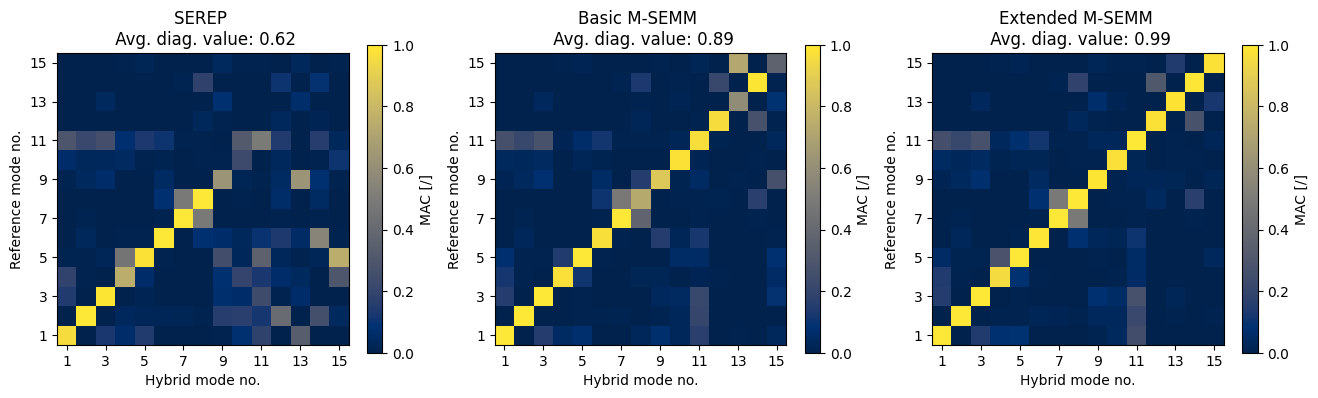

In [11]:
plt.figure(figsize=(16,4))

# SEREP
plt.subplot(131)
MAC_mat = pyFBS.mac(eig_vec_ref, eig_vec_serep)
plt.imshow(MAC_mat, origin = 'lower', cmap = 'cividis', vmin = 0., vmax = 1)

plt.title('SEREP \n Avg. diag. value: '+ "{:.2f}".format(np.mean(np.diagonal(MAC_mat))), fontsize=12)
plt.xlabel('Hybrid mode no.')
plt.ylabel('Reference mode no.')

plt.xticks(np.arange(m_ov)[::2],np.arange(1,m_ov+1)[::2])
plt.yticks(np.arange(m_ov)[::2],np.arange(1,m_ov+1)[::2])

cbar = plt.colorbar(orientation="vertical")
cbar.set_label('MAC [/]')

# Basic M-SEMM
plt.subplot(132)
MAC_mat = pyFBS.mac(eig_vec_ref, eig_vec_semm_bas)
plt.imshow(MAC_mat, origin = 'lower', cmap = 'cividis', vmin = 0., vmax = 1)

plt.title('Basic M-SEMM \n Avg. diag. value: '+ "{:.2f}".format(np.mean(np.diagonal(MAC_mat))), fontsize=12)
plt.xlabel('Hybrid mode no.')
plt.ylabel('Reference mode no.')

plt.xticks(np.arange(m_ov)[::2],np.arange(1,m_ov+1)[::2])
plt.yticks(np.arange(m_ov)[::2],np.arange(1,m_ov+1)[::2])

cbar = plt.colorbar(orientation="vertical")
cbar.set_label('MAC [/]')

# Extended M-SEMM
plt.subplot(133)
MAC_mat = pyFBS.mac(eig_vec_ref, eig_vec_semm_ext)
plt.imshow(MAC_mat, origin = 'lower', cmap = 'cividis', vmin = 0., vmax = 1)

plt.title('Extended M-SEMM \n Avg. diag. value: '+ "{:.2f}".format(np.mean(np.diagonal(MAC_mat))), fontsize=12)
plt.xlabel('Hybrid mode no.')
plt.ylabel('Reference mode no.')

plt.xticks(np.arange(m_ov)[::2],np.arange(1,m_ov+1)[::2])
plt.yticks(np.arange(m_ov)[::2],np.arange(1,m_ov+1)[::2])

cbar = plt.colorbar(orientation="vertical")
cbar.set_label('MAC [/]')

## Perform expansion in frequency domain

#### Acquire response models

In [12]:
# assume collocated inputs and outputs
df_imp_P = df_chn_P
df_imp_O = df_chn_O

# reference - overlay model with higher spatial resolution
MK_O.frf_synth(df_chn_P, df_imp_P,
             f_start = freq_min, f_end = freq_max, f_resolution = 1,
             limit_modes = m_ov, modal_damping = dam_ov,
             frf_type = "receptance")

Y_ref = MK_O.frf

# parent
MK_P.frf_synth(df_chn_P, df_imp_P,
                 f_start = freq_min, f_end = freq_max, f_resolution = 1,
                 limit_modes = m_par_MSEMM, modal_damping = dam_par,
                 frf_type = "receptance")

Y_par = MK_P.frf

# overlay
MK_O.frf_synth(df_chn_O, df_imp_O,
             f_start = freq_min, f_end = freq_max, f_resolution = 1,
             limit_modes = m_ov, modal_damping = dam_ov,
             frf_type = "receptance")

Y_ov = MK_O.frf

### a) Basic SEMM

In [13]:
Y_semm_FBS_bas = pyFBS.expansion.semm(Y_par, Y_ov, df_chn_P, df_imp_P, df_chn_O, df_imp_O, SEMM_type = 'basic')

### b) Extended SEMM

In [14]:
Y_semm_FBS_ext = pyFBS.expansion.semm(Y_par, Y_ov, df_chn_P, df_imp_P, df_chn_O, df_imp_O, SEMM_type = 'extended')

### c) Results: SEMM vs M-SEMM

In [15]:
sel_dof = 17

<>:17: SyntaxWarning: invalid escape sequence '\,'
<>:17: SyntaxWarning: invalid escape sequence '\,'
C:\Users\ga83top\AppData\Local\Temp\ipykernel_10916\2278838928.py:17: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel('$|Y|\,[\mathrm{m/N}]$')


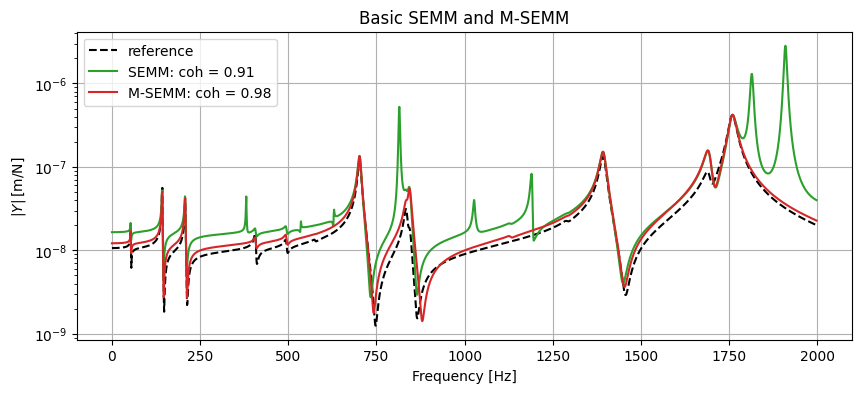

In [16]:
coh_FBS = pyFBS.utility.coh_frf(Y_ref[:,sel_dof,sel_dof],
                        Y_semm_FBS_bas[:,sel_dof,sel_dof])

coh_CMS = pyFBS.utility.coh_frf(Y_ref[:,sel_dof,sel_dof],
                        Y_semm_CMS_bas[:,sel_dof,sel_dof])

SEMM_label = 'SEMM: coh = ' + str(coh_FBS.round(2))
MSEMM_label = 'M-SEMM: coh = ' + str(coh_CMS.round(2))


plt.figure(figsize=(10,4))
plt.title('Basic SEMM and M-SEMM')
plt.semilogy(np.abs(Y_ref[:,sel_dof,sel_dof]),'--',label = 'reference',c='k')
plt.semilogy(np.abs(Y_semm_FBS_bas[:,sel_dof,sel_dof]),label = SEMM_label,c='C2')
plt.semilogy(np.abs(Y_semm_CMS_bas[:,sel_dof,sel_dof]),label = MSEMM_label,c='C3')
plt.xlabel('Frequency [Hz]')
plt.ylabel('$|Y|\,[\mathrm{m/N}]$')
plt.legend()
plt.grid()

<>:16: SyntaxWarning: invalid escape sequence '\,'
<>:16: SyntaxWarning: invalid escape sequence '\,'
C:\Users\ga83top\AppData\Local\Temp\ipykernel_10916\1047995775.py:16: SyntaxWarning: invalid escape sequence '\,'
  plt.ylabel('$|Y|\,[\mathrm{m/N}]$')


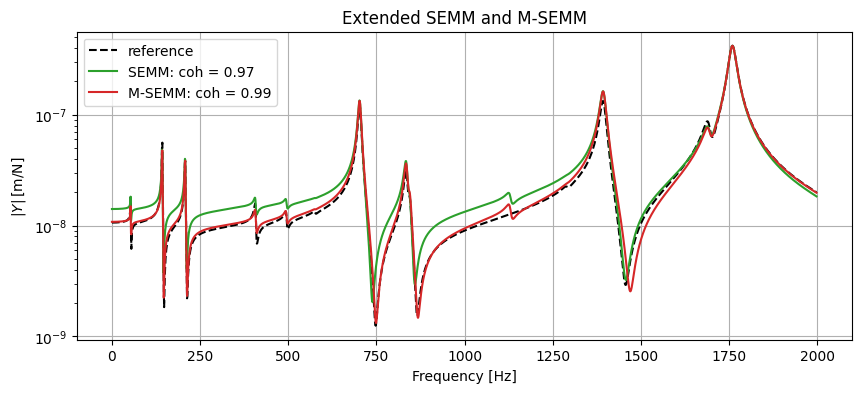

In [17]:
coh_FBS = pyFBS.utility.coh_frf(Y_ref[:,sel_dof,sel_dof],
                        Y_semm_FBS_ext[:,sel_dof,sel_dof])

coh_CMS = pyFBS.utility.coh_frf(Y_ref[:,sel_dof,sel_dof],
                        Y_semm_CMS_ext[:,sel_dof,sel_dof])

SEMM_label = 'SEMM: coh = ' + str(coh_FBS.round(2))
MSEMM_label = 'M-SEMM: coh = ' + str(coh_CMS.round(2))

plt.figure(figsize=(10,4))
plt.title('Extended SEMM and M-SEMM')
plt.semilogy(np.abs(Y_ref[:,sel_dof,sel_dof]),'--',label = 'reference',c='k')
plt.semilogy(np.abs(Y_semm_FBS_ext[:,sel_dof,sel_dof]),label = SEMM_label,c='C2')
plt.semilogy(np.abs(Y_semm_CMS_ext[:,sel_dof,sel_dof]),label = MSEMM_label,c='C3')
plt.xlabel('Frequency [Hz]')
plt.ylabel('$|Y|\,[\mathrm{m/N}]$')
plt.legend()
plt.grid()